In [ ]:
# Transformers example -> Reverseing sequence of numbers
print("Hey")

# Bayesian inference with transformer-based diffusion models

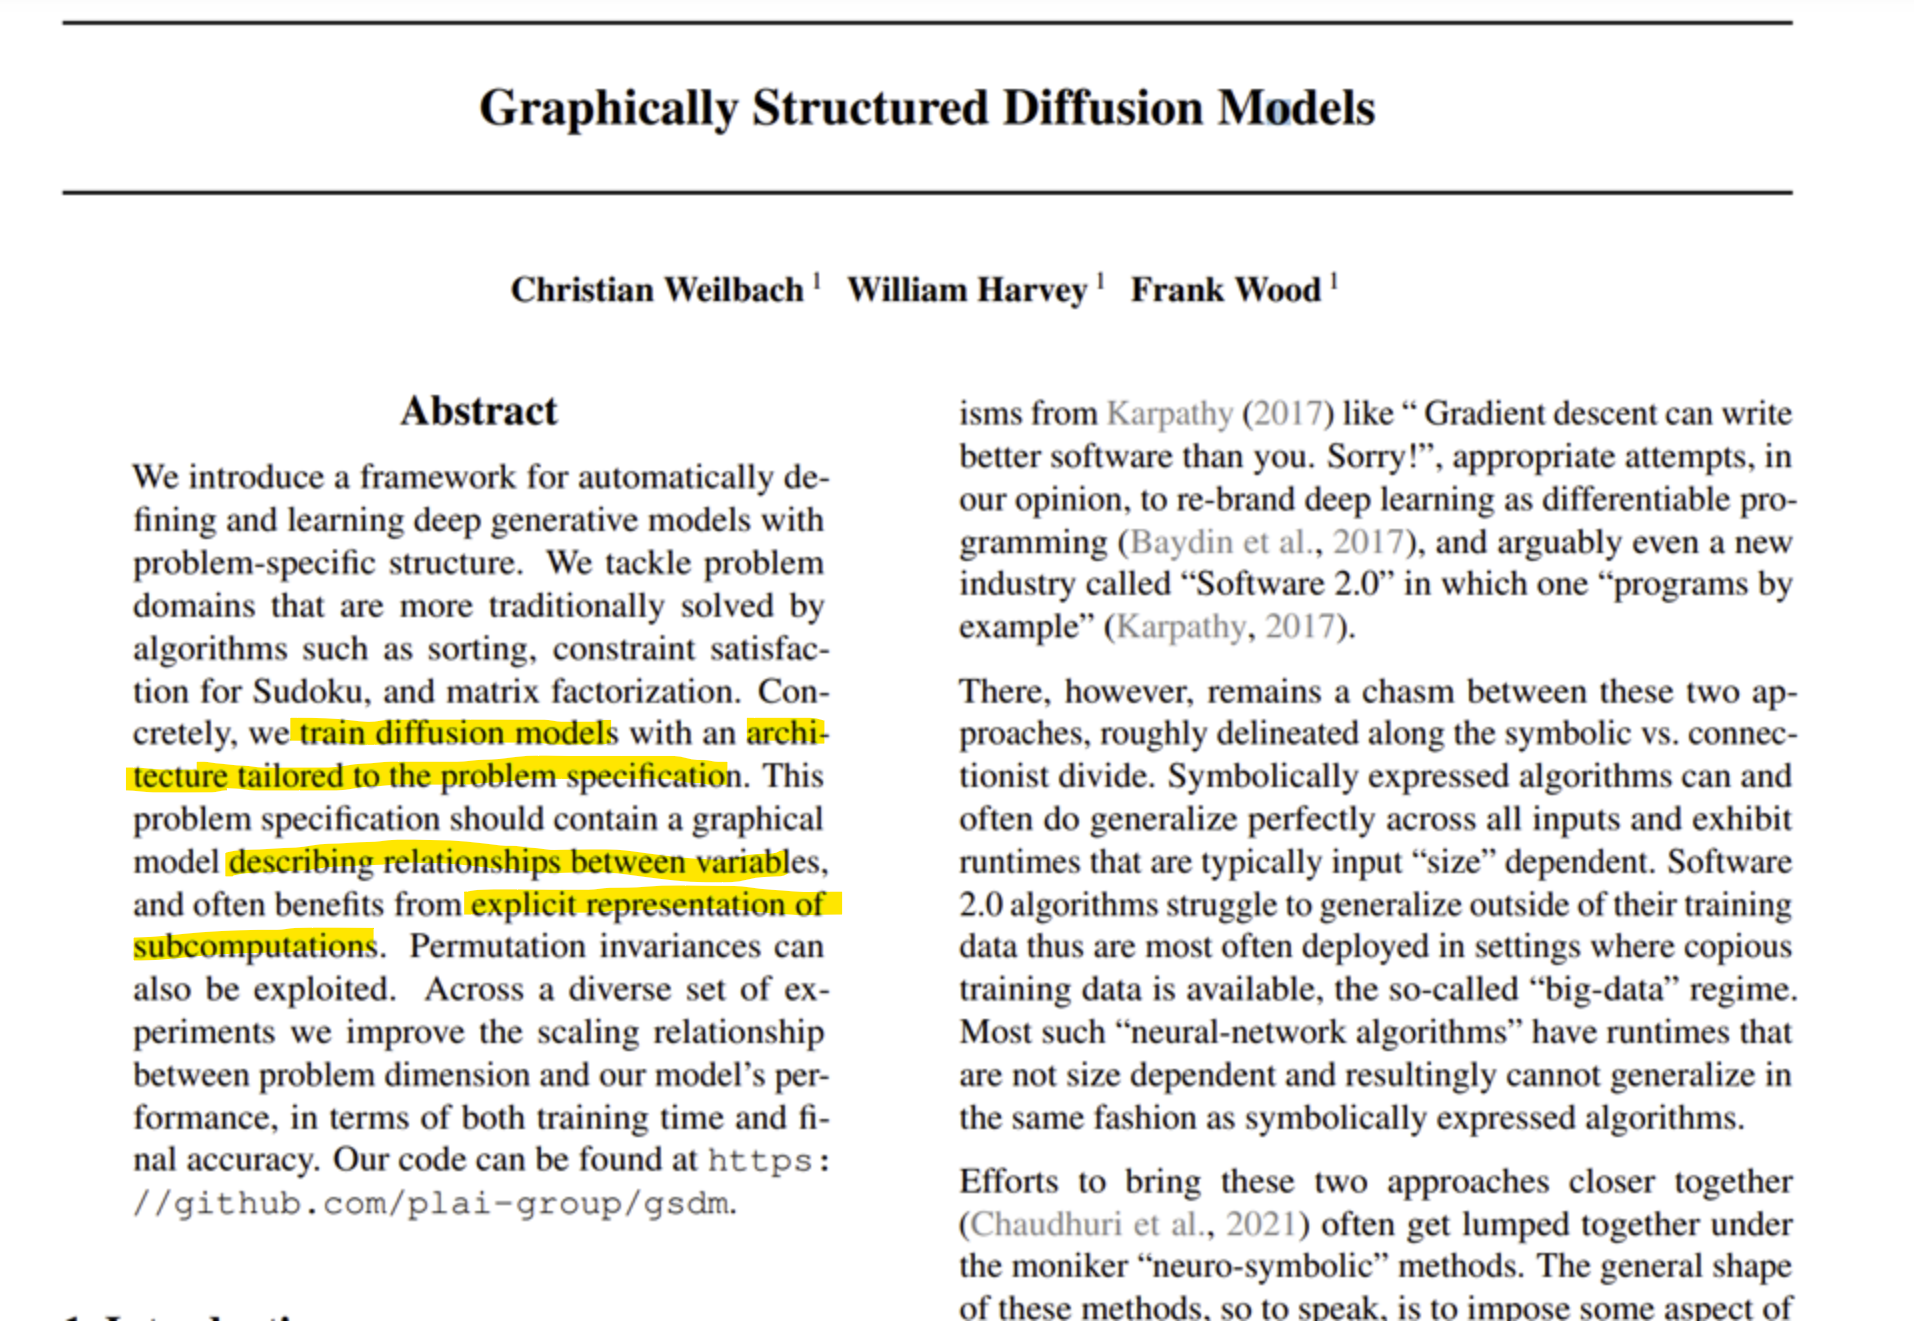

* Problem specification in form of a graphical model describing all dependencies.
* Structure incoperated in diffusion models through structured masking of self-attention.
* Tasks: Sorting, Sudoku, and matrix factorization.

## Diffusion models

* Trained through denoising score matching objective

$$ \mathcal{L}(\phi) = \mathbb{E}_{t \sim Unif(0,1)} \left[ \lambda(t) \mathbb{E}_{x_0, x_t \sim p(x_0)p(x_t|x_0)}\left[ || s_\phi(x_t, t) - \nabla_{x_t} \log p(x_t|x_0)||_2^2 \right] \right] $$

* Here $\lambda(t)$ can be an positive weighting function. Then $s_\phi(x_t, t) \approx \nabla_{x_t}\log p(x_t)$.

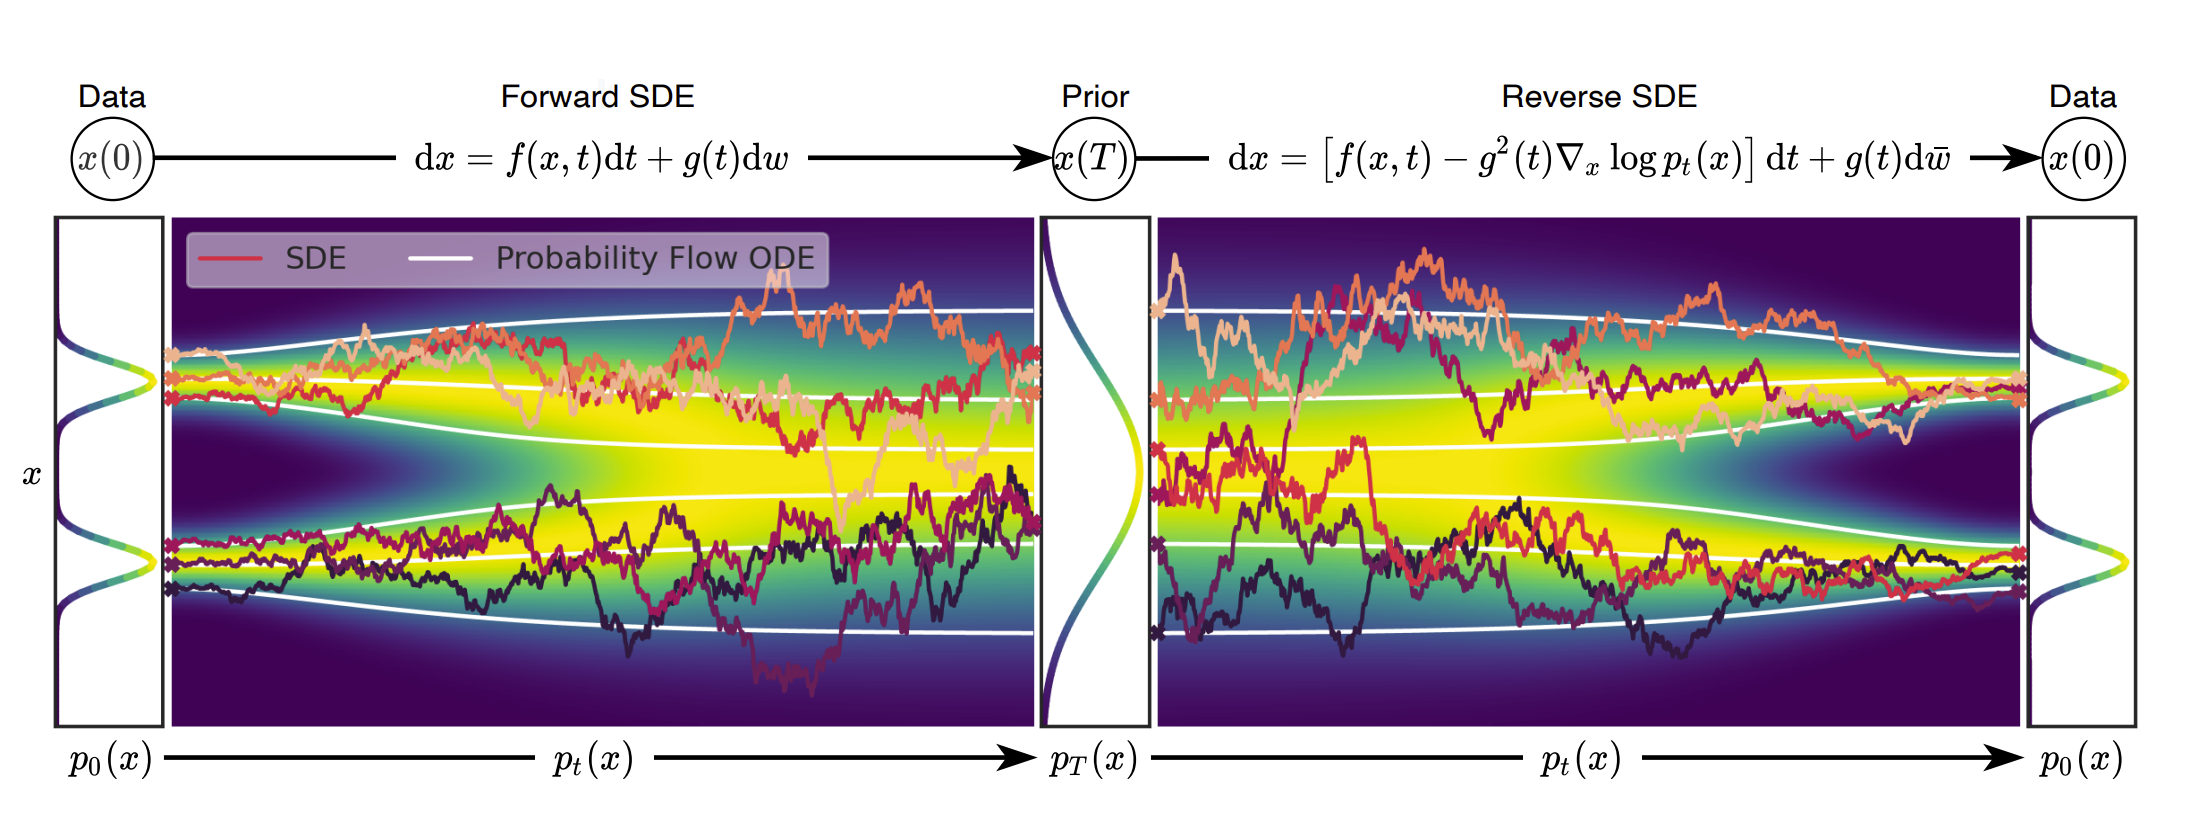

## The model

## The model

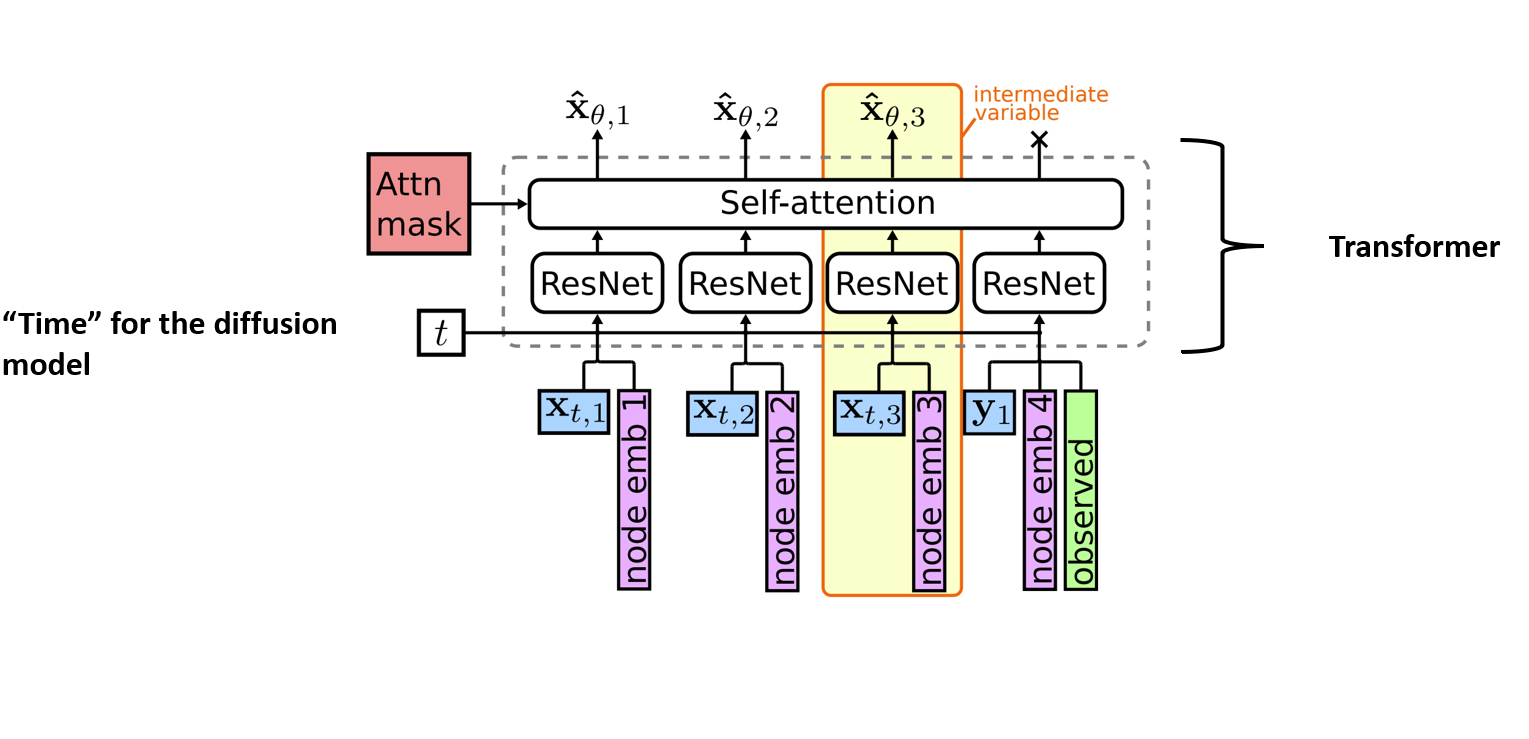

## The model
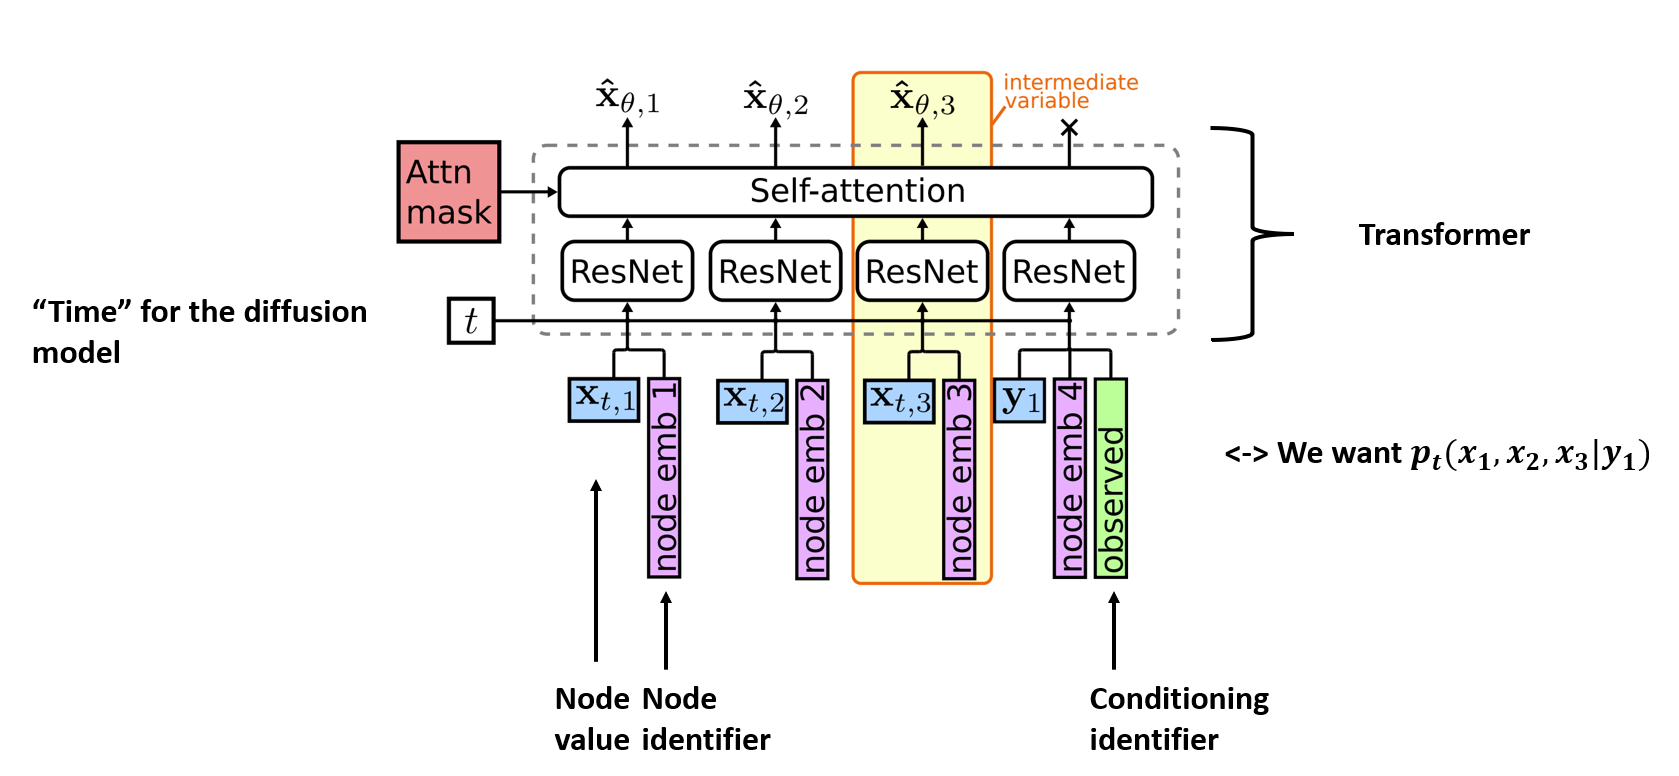

## The model
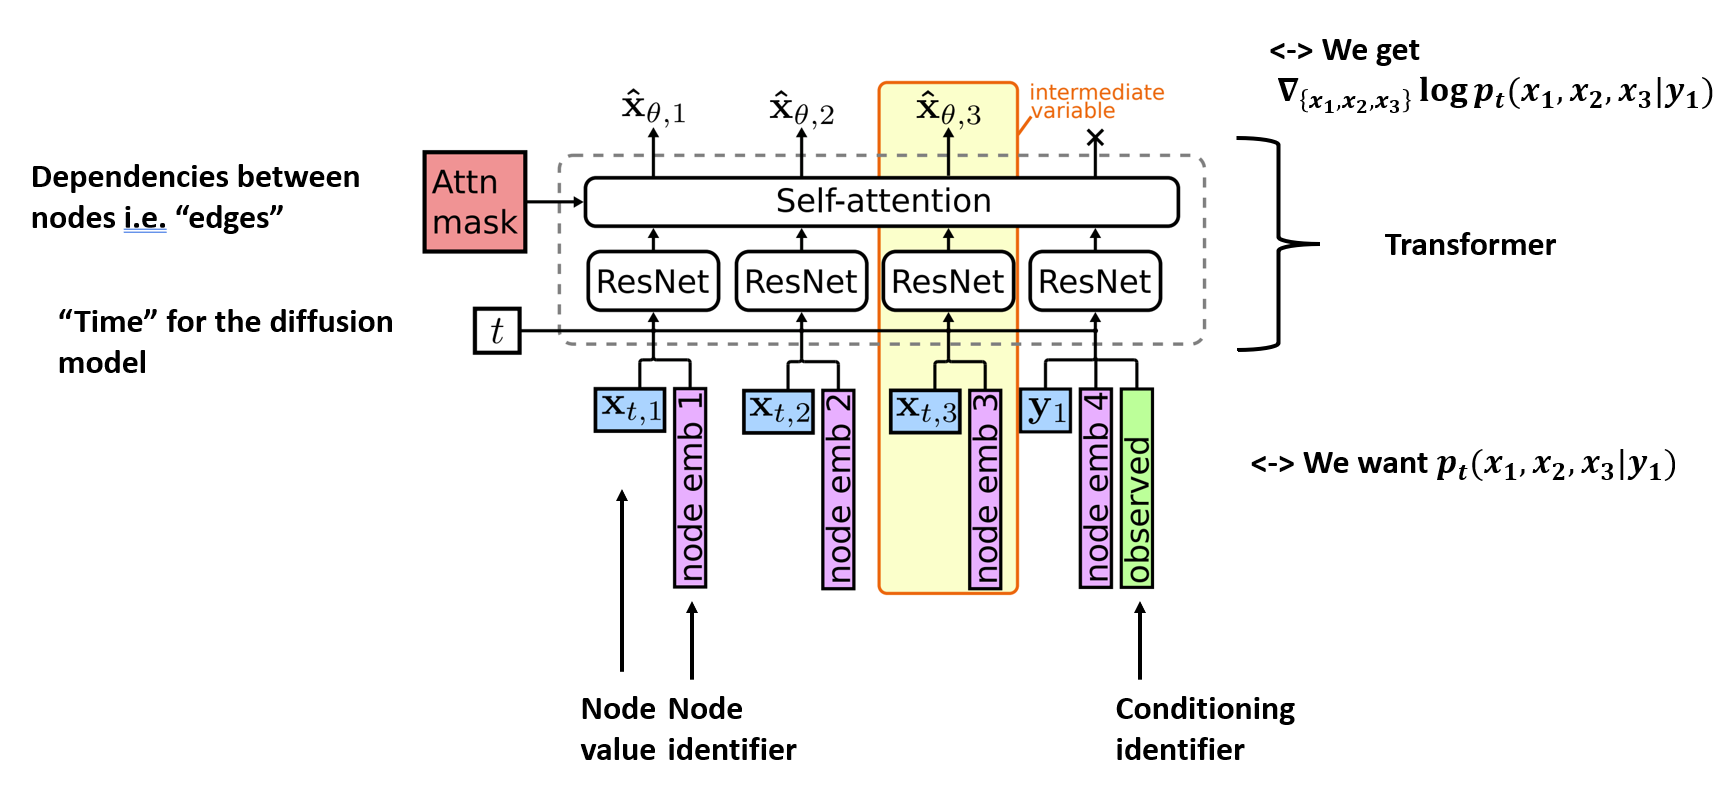

## Dependencies
* Can be directly extracted from a specified graphical model

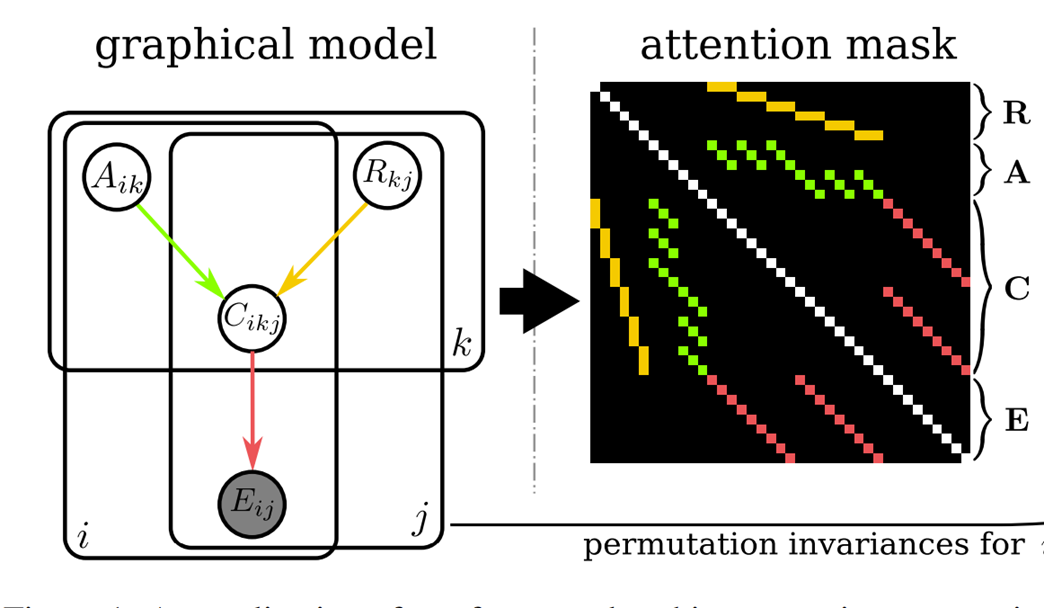

* Limitations
    * We need to know all the dependencies!
    * Dependencies do change if condition on different nodes!
    
* Do we need it?
    * No it can be learned.
    * We can provide partial information on dependencies.

# Results

### Specifing dependencies works well in terms of "accuracy"
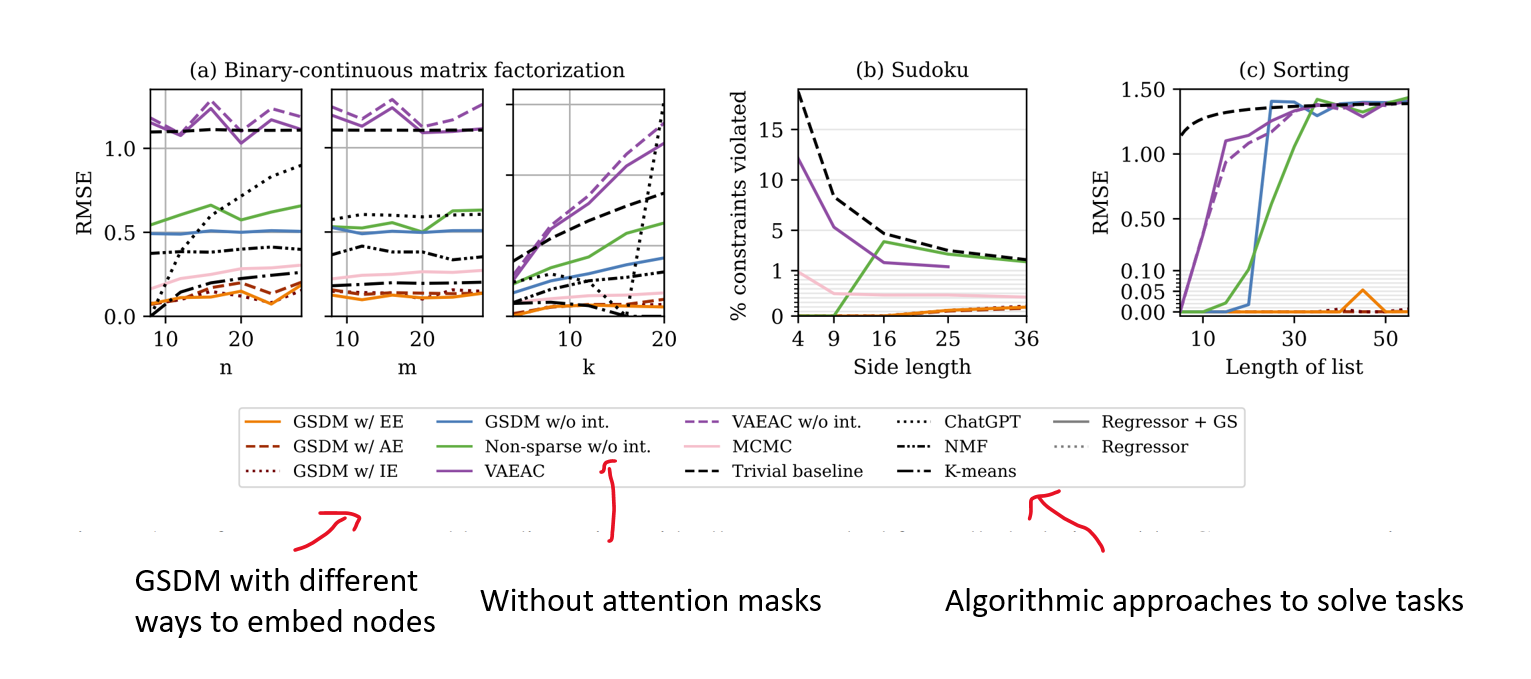

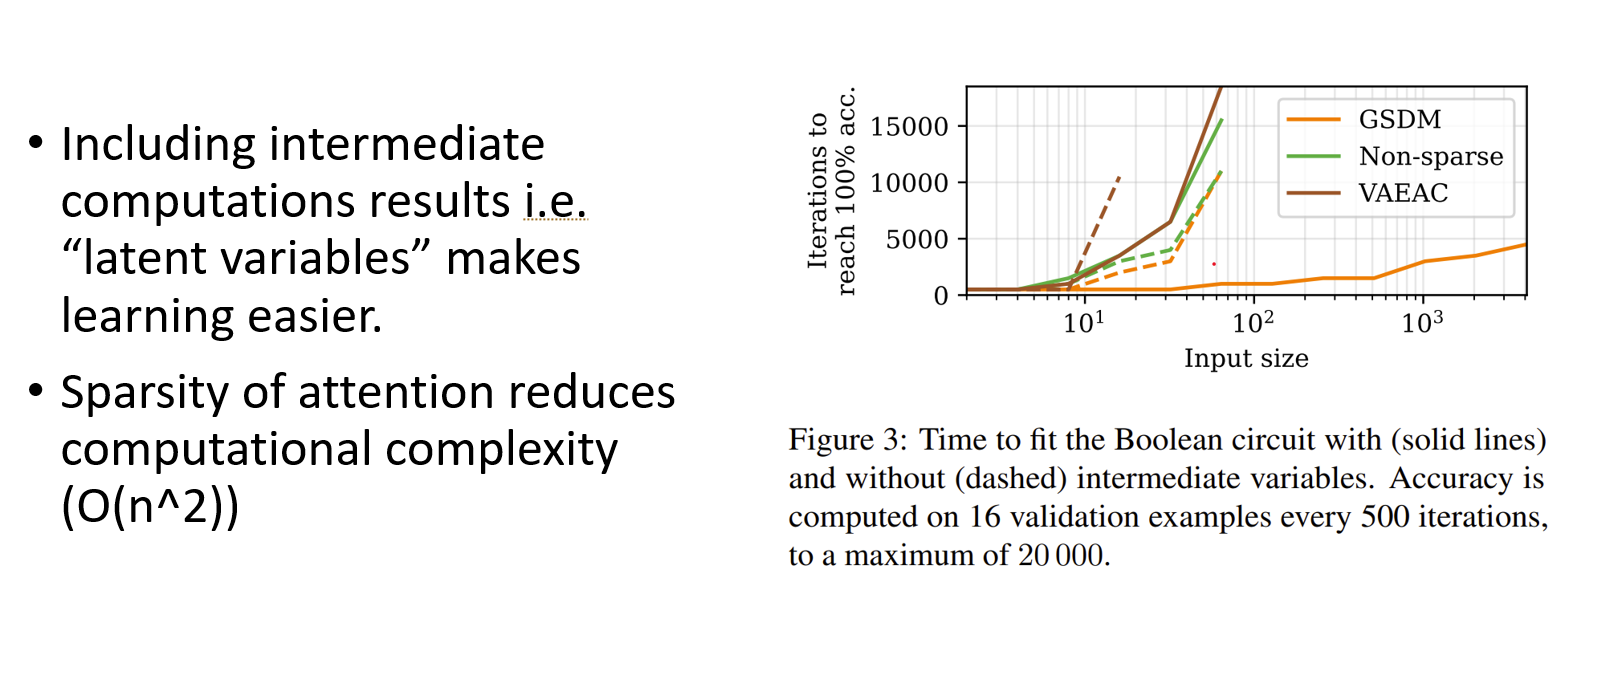

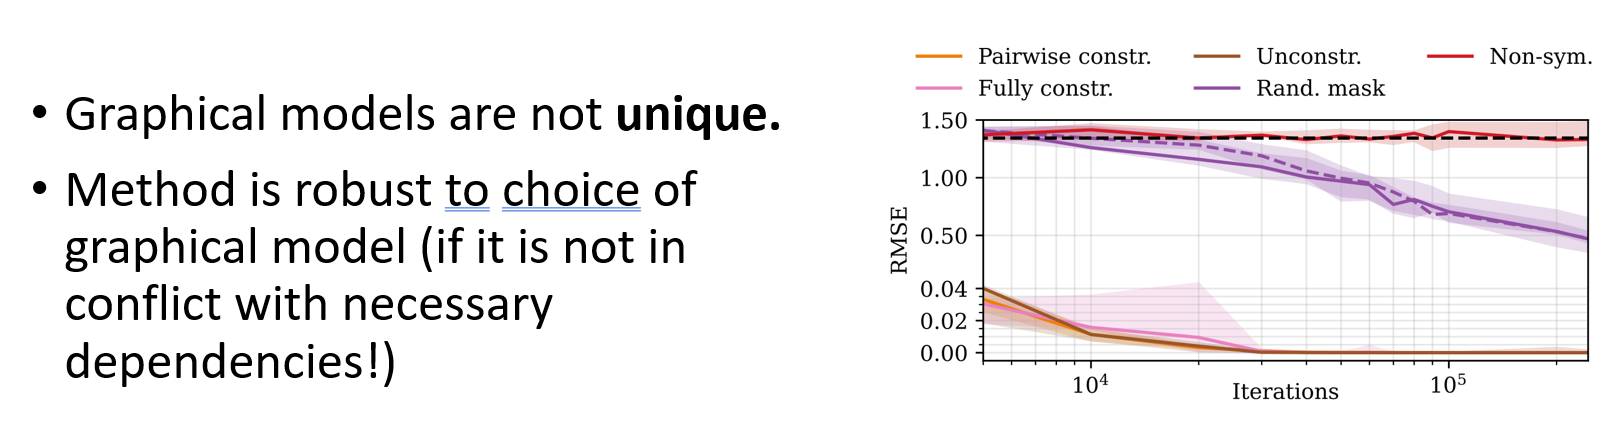

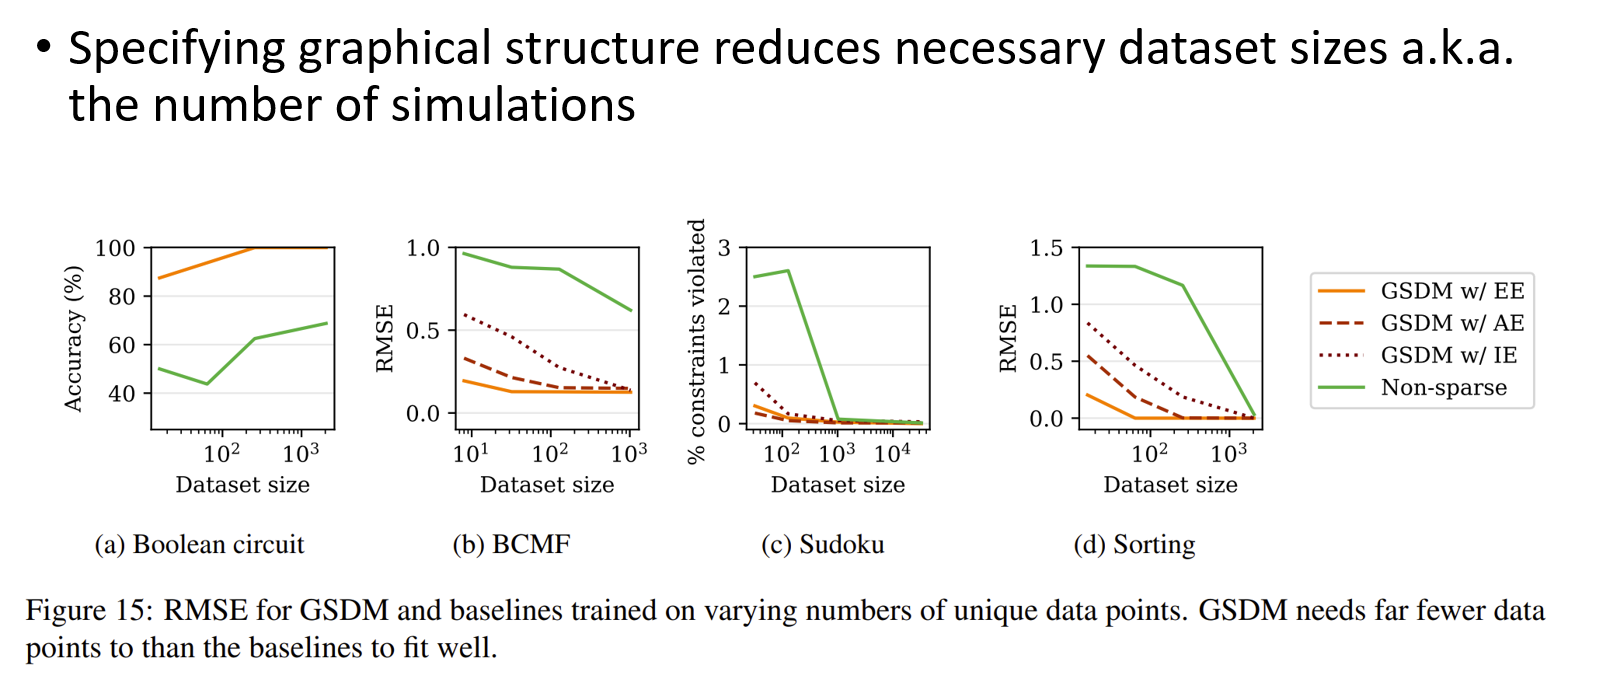

# Conclusion

* Nice that one can easily constrain dependencies is great.
* But I think that the overall flexibility offered by the Transformer is much more interesting
    * Arbitrary conditionals can be jointly learned
    * Arbitrary marginals can be learned as we can just "leave" out variables (Transformer can handle varying sequence length)
    * Nodes can have additional "metadata"
        * Time series are random variables evaluated at different times! -> Time as metadata
        * Generally stochastic process with some index set.
        * Different distributions can be specified as metadata 

In [70]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import seaborn as sns

from functools import partial

import haiku as hk
import optax

from probjax.utils.odeint import _odeint

from probjax.nn.transformers import Transformer

from sbi.analysis import pairplot
import numpy as np

In [71]:
jax.devices()

[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

# Let's look at (jax) code!

In [129]:
def generate_data(key, n):
    key1, key2, key3 = jrandom.split(key,3)
    theta1 = jrandom.normal(key1, (n, 1))  * 3 # Some prior on a parameter
    x1 = 2*jnp.sin(theta1) + jrandom.normal(key2, (n, 1)) * 0.5 # Some data generated from the parameter 
    return jnp.concatenate([theta1,x1], axis=1).reshape(n, -1, 1)
    

data = generate_data(jrandom.PRNGKey(1), 10000)
nodes_max = data.shape[1]

node_ids = jnp.arange(nodes_max)

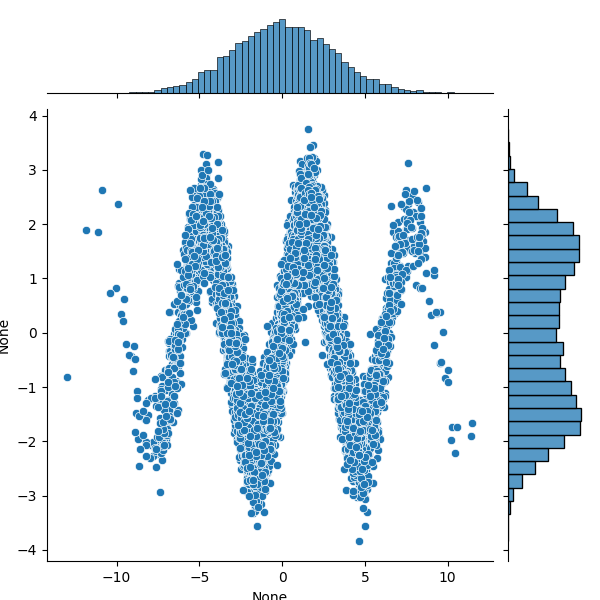

In [73]:
_ = sns.jointplot(x=data[:, 0, 0], y=data[:, 1, 0])

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

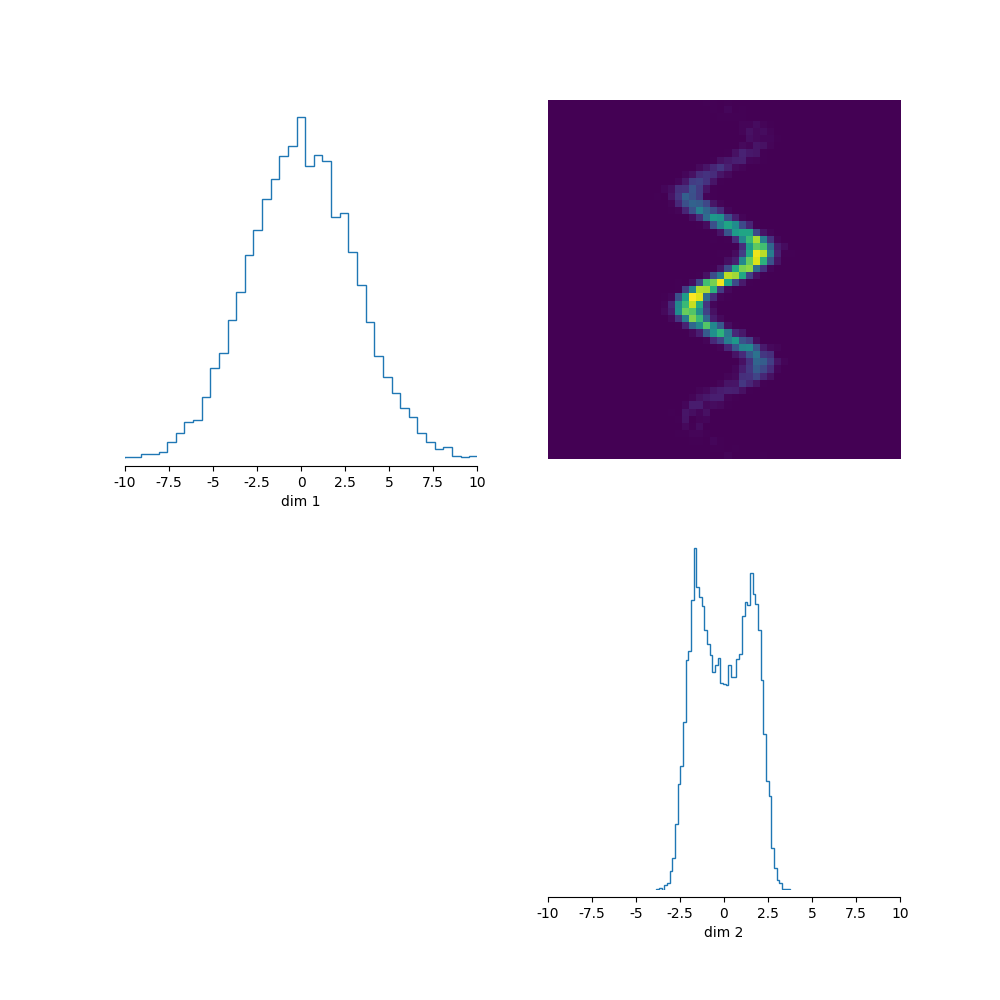

In [74]:
pairplot(np.array(data[:, :, 0]), limits=[[-10, 10], [-10, 10], [-10, 10]])

In [75]:
key = jrandom.PRNGKey(0)

In [76]:
from probjax.nn.helpers import SinusoidalEmbedding

## The model

In [77]:

def model(t, x, node_ids, condition_mask):
    batch_size, seq_len, node_dim = x.shape
    condition_mask = condition_mask.astype(jnp.int32).reshape(-1,seq_len, 1)
    node_ids = node_ids.reshape(-1,seq_len)
    t = t.reshape(-1,1, 1)
    
    # Embed values and conditions
    dim = 20
    _dim = dim // 2
    embedding_net = hk.nets.MLP([dim, _dim])    # Value embedding net
    embedding_id_nets = hk.Embed(nodes_max, _dim)   # Node id embedding nets
    embedding_time = SinusoidalEmbedding(_dim)  # Time embedding net
    
    # Conditioning embedding
    condition_embedding = hk.get_parameter("condition_embedding", shape=(1,1,dim), init=hk.initializers.RandomNormal(mean=1.))
    condition_embedding = condition_embedding * condition_mask
    

    # Transformer
    model = Transformer(num_heads=4, num_layers=3, attn_size=5, dropout_rate=0.0, widening_factor=2)

    # Embed inputs and broadcast
    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    time_embeddings = embedding_time(t)
    value_embeddings, id_embeddings, time_embeddings = jnp.broadcast_arrays(value_embeddings, id_embeddings, time_embeddings)
    
    # Concatenate embeddings
    x_encoded = jnp.concatenate([value_embeddings, id_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding
        

    # Encode
    mask = (jnp.eye(seq_len, dtype=jnp.int32) + node_ids[..., :, None] != node_ids[..., None, :]).astype(jnp.bool_)
    h = model(x_encoded, context=time_embeddings, mask=mask)

    # Decode
    out = hk.Linear(1)(h)

    out = out * (1-condition_mask)
    return out


In [128]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, jnp.zeros_like(node_ids))

In [79]:
jax.tree_map(lambda x: x.shape, params)

{'embed': {'embeddings': (2, 10)},
 'linear': {'b': (1,), 'w': (20, 1)},
 'mlp/~/linear_0': {'b': (20,), 'w': (1, 20)},
 'mlp/~/linear_1': {'b': (10,), 'w': (20, 10)},
 'transformer/layer_norm': {'offset': (20,), 'scale': (20,)},
 'transformer/layer_norm_1': {'offset': (20,), 'scale': (20,)},
 'transformer/layer_norm_2': {'offset': (20,), 'scale': (20,)},
 'transformer/layer_norm_3': {'offset': (20,), 'scale': (20,)},
 'transformer/layer_norm_4': {'offset': (20,), 'scale': (20,)},
 'transformer/layer_norm_5': {'offset': (20,), 'scale': (20,)},
 'transformer/layer_norm_6': {'offset': (20,), 'scale': (20,)},
 'transformer/linear': {'b': (40,), 'w': (20, 40)},
 'transformer/linear_1': {'b': (20,), 'w': (40, 20)},
 'transformer/linear_2': {'b': (20,), 'w': (10, 20)},
 'transformer/linear_3': {'b': (40,), 'w': (20, 40)},
 'transformer/linear_4': {'b': (20,), 'w': (40, 20)},
 'transformer/linear_5': {'b': (20,), 'w': (10, 20)},
 'transformer/linear_6': {'b': (40,), 'w': (20, 40)},
 'transfor

In [80]:
jax.tree_util.tree_reduce(lambda x,y: x+y, jax.tree_map(lambda x: x.size, params))

11271

In [81]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids, jnp.zeros_like(node_ids))

## Setting up the diffusion process

In [82]:
# VPSDE 
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

# Defines the SDE
def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

# Defines the marginal moments conditioned on x0
def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

# Samples from p(x_t|x_o)
def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

# Score of p(x_t|x_o) for training
log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [118]:
ids = jax.random.choice(key, jnp.arange(2), (10000,2))

In [119]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)

## Writing down the loss
* What we want
    * Correct marginals $p(\theta), p(x)$
    * Correct conditionals $p(\theta|x), p(x|\theta)$
    * Correct joint $p(\theta|x)$
    
* Base loss still same, but with some modifications
$$ \mathcal{L}(\phi) = \mathbb{E}_{t \sim Unif(0,1)} \left[ \lambda(t) \mathbb{E}_{x_0, x_t \sim p(x_0)p(x_t|x_0)}\left[ || s_\phi(x_t, t) - \nabla_{x_t} \log p(x_t|x_0)||_2^2 \right] \right] $$
 

In [120]:



def loss_fn(params, key, batch_size= 256):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=T_min, maxval=1.0)
    batch_xs = generate_data(rng_data, batch_size) # n, T_max, 1

    # Permute sequence -> randomly permute the sequence of data to promote node identification
    ids = jax.random.choice(rng_permute_ids,jnp.array([[0,1], [0,0], [1,1]]), shape=(batch_xs.shape[0],), p=jnp.array([0.8,0.1,0.1]), axis=0)
    ids = ids[...,None]
    batch_xs = jnp.take_along_axis(batch_xs, ids, axis=1)
    # Condition mask -> randomly condition on some data -> Sample more frequently no condition
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0,0], [1,0], [0,1]]), shape=(batch_size, ), p=jnp.array([0.333, 0.333, 0.333]), axis=0)
    condition_mask = condition_mask[..., None]


    # Forward diffusion, do not perturb conditioned data
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
    batch_noisy_xs = batch_noisy_xs * (1-conditi on_mask) + batch_xs * condition_mask # Condition on the data

    # Predict score
    score_pred = model_fn(params, rng_model, times, batch_noisy_xs, ids[...,0], condition_mask[...,0])
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    
    # Magical weighting function
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times)
    
    # Masked loss
    loss = jnp.mean(jnp.sum((1- condition_mask)*lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


In [121]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [122]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [123]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [124]:
# Compile
_ = update(replicated_params, jax.random.split(key, (n_devices,)), replicated_opt_state)

## Train

In [130]:
key = jrandom.PRNGKey(0)
for _ in range(10):
    l = 0
    for i in range(500):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] /500
    print(l)
params = jax.tree_map(lambda x: x[0], replicated_params)

0.60322577
0.60521
0.6020118
0.6013908
0.60161316
0.60311466
0.6025631
0.5999352
0.60012877
0.5997738


In [ ]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [ ]:
%matplotlib inline
# Check vector field
x, y = jnp.meshgrid(jnp.arange(-12, 12, 0.5), jnp.arange(-4, 4, 0.3))
pos = jnp.dstack((x, y)).reshape(-1, nodes_max, 1)
vs = model_fn(params, key, jnp.ones((pos.shape[0],1, 1)) * 0.00001, pos, node_ids, jnp.zeros_like(node_ids))

plt.quiver(pos[:, 0], pos[:, 1], vs[:, 0], vs[:, 1], scale=100)

## Sampling using backward SDE

In [131]:
from functools import partial
from probjax.utils.sdeint import sdeint

condition_mask = jnp.array([0,0])
condition_value = jnp.array([0., 0])

# Reverse SDE drift
def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask):
    score = model_fn(params, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask[:len(node_ids)])
    return f

# Reverse SDE diffusion
def diffusion_backward(t,x, node_ids=node_ids,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t) 
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [110]:

def sample_fn(key, shape, node_ids=node_ids, time_steps=500, condition_mask=jnp.zeros((nodes_max,), dtype=int), condition_value=jnp.zeros((nodes_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    # Sample from noise distribution at time 1
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.) + marginal_mean(0, 1.)
    # If conditioned on certain variables, replace with conditioned value
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    # Sove backward sde
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids, condition_mask), lambda t, x: diffusion_backward(t, x, node_ids, condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [93]:
import seaborn as sns


def plot(data, condition_mask,condition_value, node_ids=node_ids, num_samples=2000):
    fig = sns.jointplot(x = data[:num_samples, 0, 0], y=data[:num_samples, 1, 0], color="C1", alpha=0.1)
    
    samples = sample_fn(jrandom.PRNGKey(0), (num_samples,), node_ids, condition_mask=condition_mask, condition_value=condition_value)
    fig.x = samples[:, -1, 0]
    fig.y = samples[:, -1, 1]
    fig.plot_joint(plt.scatter, alpha=0.1)
    
    if jnp.all(condition_mask[0] == 0):
        sns.histplot(samples[:, -1, 0], ax=fig.ax_marg_x, color="C0")
    else:
        fig.ax_marg_x.vlines(condition_value[0], 0, num_samples, color="C0", lw=5)
        
    if jnp.all(condition_mask[1] == 0):
        plt.sca(fig.ax_marg_x)
        sns.histplot(y=samples[:, -1, 1], ax=fig.ax_marg_y, color="C0", orientation="horizontal")
    else:
        fig.ax_marg_y.hlines(condition_value[1], 0, num_samples, color="C0", lw=5)

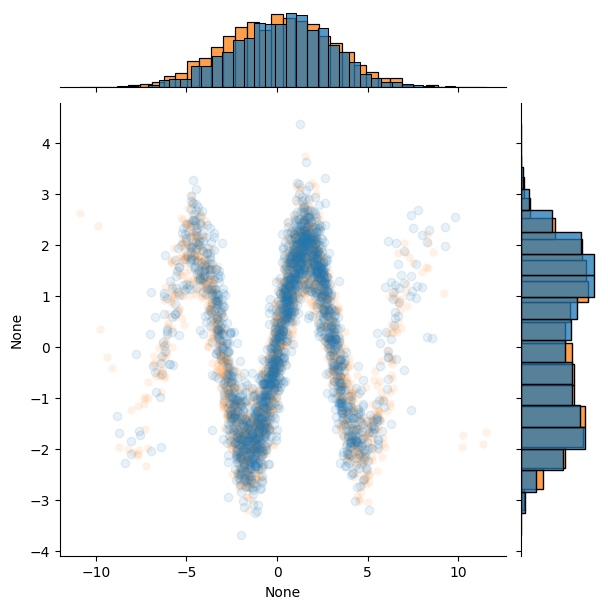

In [31]:
plot(data, condition_mask, condition_value, node_ids = jnp.array([0,1]))

## Result

In [133]:
%matplotlib widget


num_samples = 1000
# Create a jointplot
g = sns.jointplot(x=data[:num_samples, 0, 0], y=data[:num_samples, 1, 0], color="C1", alpha=0.1)
g.ax_joint.set_xlim(-10, 10)
g.ax_joint.set_ylim(-5, 5)
samples = sample_fn(jrandom.PRNGKey(0), (1000,), node_ids, condition_mask=jnp.zeros((2,)), condition_value=jnp.array([0, 0]))

# Create variables to hold the marginal histogram axes
ax_marg_x = g.ax_marg_x
ax_marg_y = g.ax_marg_y
ax_joint = g.ax_joint

l_x = None
l_y = None
l = None

# Add interactivity to the jointplot
def onclick(event):
    global l
    global l_x
    global l_y
    
    if l is not None:
        l.remove()
    
    if l_x is not None:
        try:
            l_x.remove()
        except:
            pass
        
    if l_y is not None:
        try:
            l_y.remove()
        except:
            pass

    if event.inaxes == g.ax_joint:
        x_data, y_data = g.ax_joint.transData.inverted().transform((event.x, event.y))
        # Update the marginal histograms using sns.histplot
        for i in [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
            l = g.ax_joint.scatter(samples[:, i, 0], samples[:, i, 1], color="C0", alpha=0.1)
            ax_marg_x.clear()
            ax_marg_y.clear()
            ax_marg_x.set_xticks([])
            ax_marg_y.set_yticks([])
            g.plot_marginals(sns.histplot, color="C1")
            l2 = sns.histplot(x=samples[:, i, 0], ax=ax_marg_x, color='C0' ,kde=False)
            l3 = sns.histplot(y=samples[:, i, 1], ax=ax_marg_y, color='C0', orientation="horizontal", kde=False)
            g.ax_joint.set_xlim(-10, 10)
            g.ax_joint.set_ylim(-5, 5)
            g.ax_joint.figure.canvas.draw()
            
            if i < 500:
                l.remove()
                
    elif event.inaxes is ax_marg_x:
        x_data, y_data = g.ax_joint.transData.inverted().transform((event.x, event.y))
    
    
        l_x = ax_marg_x.vlines(x_data, 0, num_samples/10, color="C0", lw=5)
        g.ax_joint.figure.canvas.draw()
        
        samples_condition_x = sample_fn(jrandom.PRNGKey(0), (1000,), node_ids, condition_mask=jnp.array([1,0]), condition_value=jnp.array([x_data, 0]))
        for i in [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
            l = g.ax_joint.scatter(samples_condition_x[:, i, 0], samples_condition_x[:, i, 1], color="C0", alpha=0.1)
            ax_marg_x.clear()
            ax_marg_y.clear()
            ax_marg_x.set_xticks([])
            ax_marg_y.set_yticks([])
            g.plot_marginals(sns.histplot, color="C1")
            l_x = ax_marg_x.vlines(x_data, 0, num_samples/10, color="C0", lw=5)
            l3 = sns.histplot(y=samples_condition_x[:, i, 1], ax=ax_marg_y, color='C0', orientation="horizontal", kde=False)
            g.ax_joint.set_xlim(-10, 10)
            g.ax_joint.set_ylim(-5, 5)
            g.ax_joint.figure.canvas.draw()
            
            if i < 500:
                l.remove()
                
    elif event.inaxes is ax_marg_y:
        x_data, y_data = g.ax_joint.transData.inverted().transform((event.x, event.y))
        l_y = ax_marg_y.hlines(y_data, 0, num_samples/10, color="C0", lw=5)
        g.ax_joint.figure.canvas.draw()
        
        samples_condition_y = sample_fn(jrandom.PRNGKey(0), (1000,), node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0, y_data]))
        for i in [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
            l = g.ax_joint.scatter(samples_condition_y[:, i, 0], samples_condition_y[:, i, 1], color="C0", alpha=0.1)
            ax_marg_x.clear()
            ax_marg_y.clear()
            ax_marg_x.set_xticks([])
            ax_marg_y.set_yticks([])
            l_y = ax_marg_y.hlines(y_data, 0, num_samples/10, color="C0", lw=5)
            g.plot_marginals(sns.histplot, color="C1")
            l2 = sns.histplot(x=samples_condition_y[:, i, 0], ax=ax_marg_x, color='C0' ,kde=False)
            g.ax_joint.set_xlim(-10, 10)
            g.ax_joint.set_ylim(-5, 5)
            g.ax_joint.figure.canvas.draw()
            
            if i < 500:
                l.remove()
    


g.fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

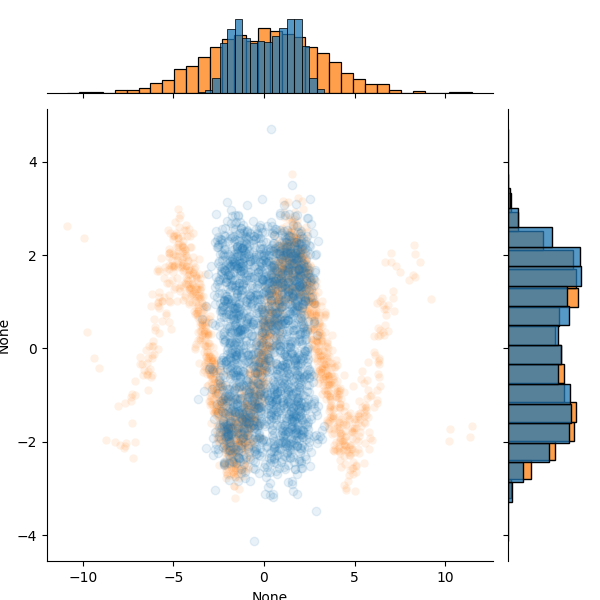

In [30]:
plot(data, condition_mask, condition_value, node_ ids = jnp.array([1,1]))

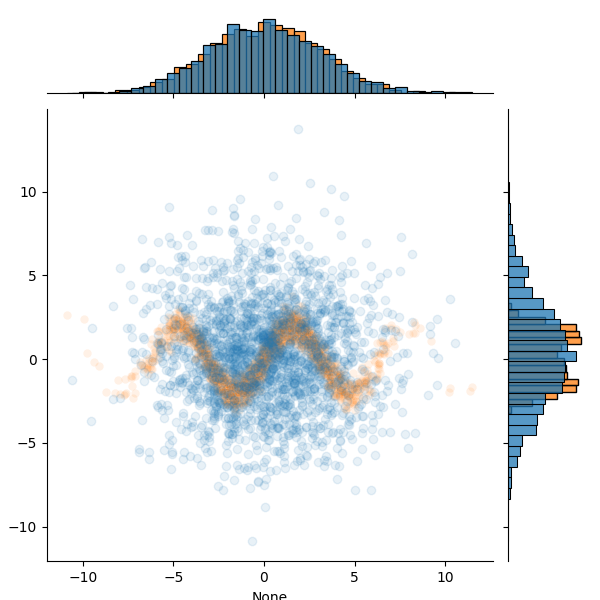

In [31]:
plot(data, condition_mask, condition_value, node_ids = jnp.array([0,0]))

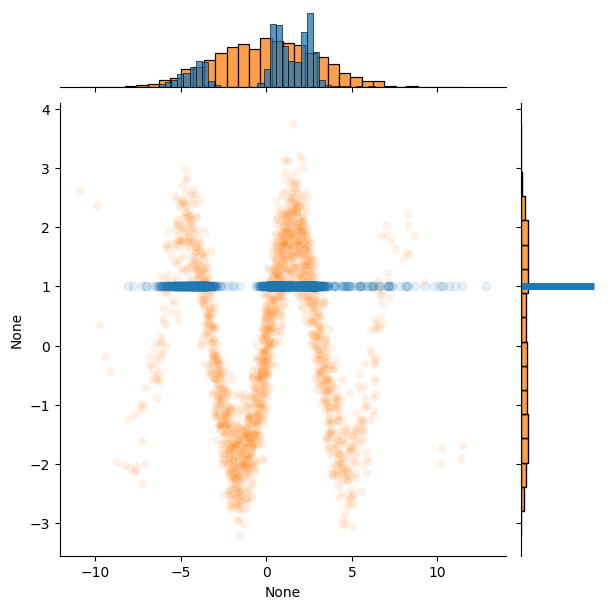

In [27]:
plot(data, jnp.array([0,1]), jnp.array([0,1]))

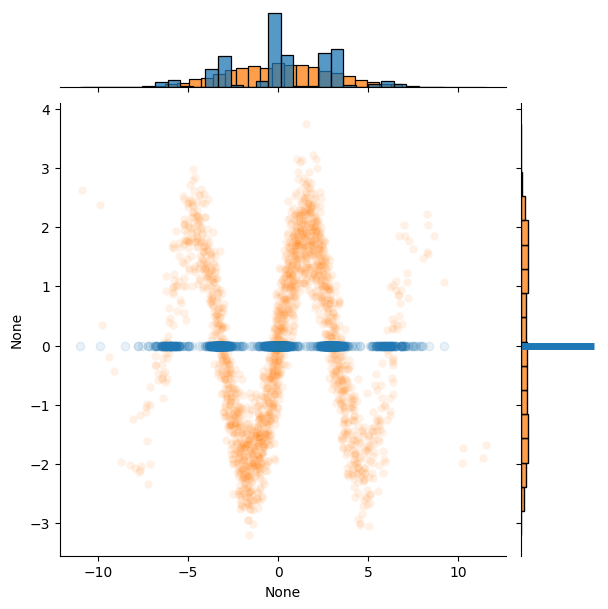

In [ ]:
plot(data, jnp.array([0,1]), jnp.array([0,0]))

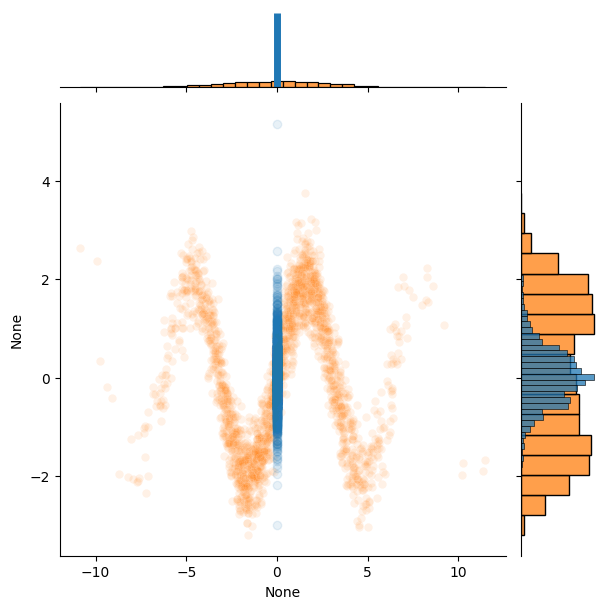

In [ ]:
plot(data, jnp.array([1,0]), jnp.array([0,0]))

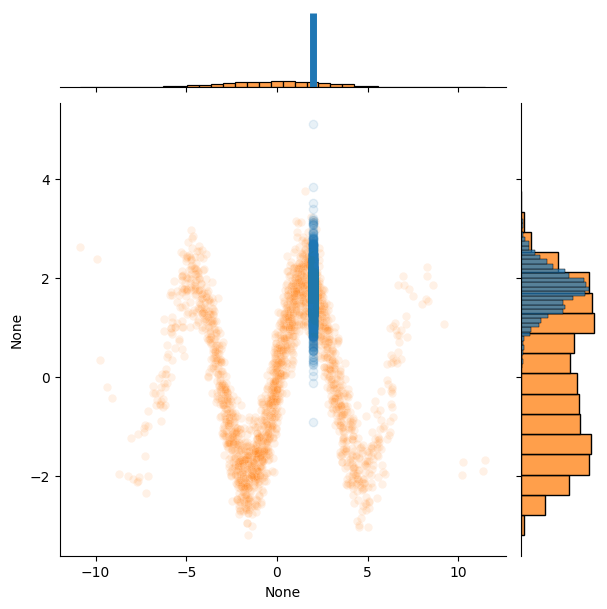

In [ ]:
plot(data, jnp.array([1,0]), jnp.array([2.,0]))

## A bot more complicated: Two moons



In [134]:
def generate_data_two_moons(key, n):
    key1, key2, key3, key4 = jrandom.split(key,4)
    theta0 = jrandom.uniform(key1, shape=(n,1))*4 - 2
    theta1 = jrandom.uniform(key2, shape=(n,1))*4 - 2
    r = jrandom.normal(key3, shape=(n,1)) * 0.01 + 0.1
    alpha = jrandom.uniform(key4, shape=(n,1)) * jnp.pi - 0.5 * jnp.pi
    sqrt2 = jnp.sqrt(2)

    x1 = (r * jnp.cos(alpha) + 0.25) + (-jnp.abs(theta0 + theta1) / sqrt2)
    x2 = (r * jnp.sin(alpha)) + ((theta1 - theta0) / sqrt2)
 
    return jnp.concatenate([theta0, theta1, x1, x2], axis=1).reshape(n, -1, 1)


data_two_moons = generate_data_two_moons(jrandom.PRNGKey(1), 10000)
T_max = data_two_moons.shape[1]

node_ids = jnp.arange(T_max)

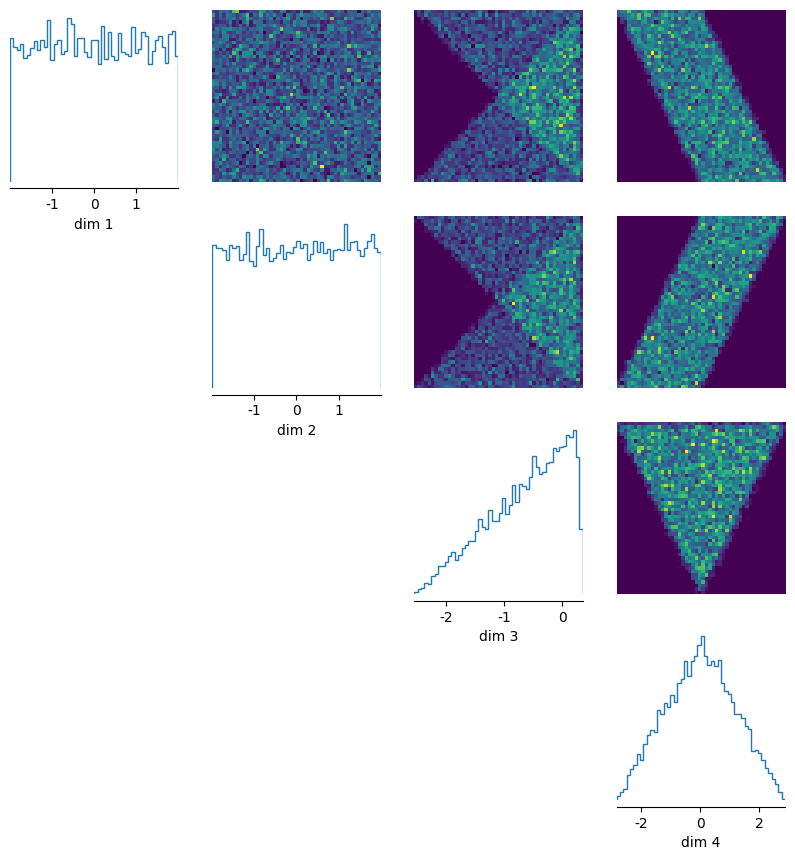

In [35]:
_ = pairplot(np.array(data_two_moons[:, :, 0]))

In [36]:

def model_two_moons(t, x, node_ids, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions
    dim = 100
    _dim = dim // 2
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim)
    embedding_time = hk.Sequential([SinusoidalEmbedding(_dim)])
    

    # Positional embedding

    model = Transformer(num_heads=4, num_layers=8, attn_size=10, dropout_rate=0.0, widening_factor=4)



    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)

    time_embeddings = embedding_time(t.reshape(-1,1,1))

    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal(stddev=0.01))
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, x.shape[1],1)
    


    x_encoded = jnp.concatenate([value_embeddings, id_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding
        
    # Encode
    h = model(x_encoded, context=time_embeddings)

    # Decode
    out = hk.Linear(1)(h)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [37]:
init_two_moons, model_fn_two_moons = hk.transform(model_two_moons)
params_two_moons = init_two_moons(key, jnp.ones(data_two_moons.shape[0]), data_two_moons, node_ids, jnp.zeros_like(node_ids))

In [38]:
params_two_moons = dict(jnp.load("transformer_based_inference_diffusion_two_moons.npz", allow_pickle=True))["params"]

In [39]:
params_two_moons = dict(params_two_moons.tolist())

In [40]:
from functools import partial

condition_mask = jnp.array([0]*T_max)
condition_value = jnp.array([0]*T_max)

def drift_backward_two_moons(t, x, node_ids=node_ids, condition_mask=condition_mask):
    #t = T - t
    score = model_fn_two_moons(params_two_moons, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask)
    return f

def diffusion_backward_two_moons(t,x, node_ids=node_ids,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [41]:

def sample_fn_two_moons(key, shape, node_ids=node_ids, time_steps=500, condition_mask=jnp.zeros((nodes_max,), dtype=int), condition_value=jnp.zeros((nodes_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    # Sample from noise distribution at time 1
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.) + marginal_mean(0, 1.)
    # If conditioned on certain variables, replace with conditioned value
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    # Sove backward sde
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward_two_moons(t, x, node_ids, condition_mask), lambda t, x: diffusion_backward_two_moons(t, x, node_ids, condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [42]:
import pandas as pd

In [139]:
%matplotlib widget
fig = plt.figure()
num_samples = 2000
condition_value = jnp.zeros((T_max,))
condition_mask = jnp.zeros((T_max,), dtype=int)
samples = jax.pmap(lambda k: sample_fn_two_moons(k, (num_samples, ), time_steps=700,node_ids=node_ids, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
samples = samples.reshape(num_samples*n_devices, -1, 4)
df = pd.DataFrame(samples[:, -1, :])

g = sns.PairGrid(df, corner=True)
g.map_diag(sns.histplot, bins=30, stat="density")
g.map_lower(sns.histplot, bins=50)


def get_index(g, ax):
    for i in range(len(g.axes)):
        for j in range(len(g.axes)):
            if j > i:
                continue
            if str(ax) == str(g.axes[i,j]):
                return i,j

def get_ax_by_index(i, j):
    for ax in g.fig.axes:
        if str(ax) == str(g.axes[i,j]):
            return ax
            
            
points = [None] * len(g.axes)
drawings = [[None] * len(g.axes) for i in range(len(g.axes))]


def onclick(event):
    global condition_mask
    global condition_value
    global drawings
    
    ax = event.inaxes
    i,j = get_index(g, ax)
    
    for l in range(len(g.axes)):
        for m in range(len(g.axes)):
            if drawings[l][m] is not None:
                drawings[l][m].remove()
                drawings[l][m] = None
        

    if i == j:
        x_data, y_data =  ax.transData.inverted().transform((event.x, event.y))
        if points[i] is not None:
            points[i].remove()
            points[i] = None
            condition_value = condition_value.at[i].set(x_data)
            condition_mask = condition_mask.at[i].set(0)
        else:
            l =  ax.vlines(x_data, 0, 1., color="red")
            points[i] = l
            condition_value = condition_value.at[i].set(x_data)
            condition_mask = condition_mask.at[i].set(1)
        
        samples = jax.pmap(lambda k: sample_fn_two_moons(k, (200, ), time_steps=200,node_ids=node_ids, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
        samples = samples.reshape(200*n_devices, -1, 4)
        df = pd.DataFrame(samples[:, -1, :])
        g.data = df 
        
        def update_diag(x, **kwargs):
            ax = plt.gca()
            i,j = get_index(g, ax)
            if condition_mask[i] != 1:
                temp1 = ax.hist(x, **kwargs)[-1]
                drawings[i][i] = temp1
                return temp1
            else:
                return None
                
        def update_lower(x,y, **kwargs):
            ax = plt.gca()
            i,j = get_index(g, ax)
            
            if condition_mask[i] != 1 or condition_mask[j] != 1:
                temp1 = ax.scatter(x,y, **kwargs)
                drawings[i][j] = temp1
                return temp1
            else:
                val1, val2 = condition_value[i], condition_value[j]
                temp2 = ax.scatter(val1, val2, color="red")
                drawings[i][j] = temp2
                return temp2

        g.map_diag(update_diag, bins=30, color="C1", edgecolor='black', alpha=0.5, density=True)
        g.map_lower(update_lower, s=.1,alpha=0.5, color="C1")
        

    
    ax.figure.canvas.draw()
                
    

g.fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

# Now for time series

In [ ]:
ts = jnp.linspace(0, 3, 100)

def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey



In [140]:
from probjax.utils.odeint import _odeint
num_timeponts = 48
time_start = 0
time_end = 10
ts_dense = jnp.linspace(time_start, time_end, 100)
def generate_data_lv(key, n):

    key1, key2, key3, key4, key5, key6, key_t = jrandom.split(key, 7)

    theta1 = jax.nn.sigmoid(jrandom.normal(key1, (n,1)))*2 + 1.
    theta2 = jax.nn.sigmoid(jrandom.normal(key2, (n,1)))*2 + 1.
    theta3 = jax.nn.sigmoid(jrandom.normal(key3, (n,1)))*2 + 1.
    theta4 = jax.nn.sigmoid(jrandom.normal(key4, (n,1)))*2 + 1.
    
    # Random time points 
    ts = jrandom.uniform(key_t, (n , num_timeponts), minval=time_start, maxval=time_end)
    predator, prey = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts_dense, theta1, theta2, theta3, theta4)
    predator = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, predator)
    prey = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, prey)
    # Noisy observation
    predator = predator + jrandom.normal(key5, predator.shape) * 0.001
    prey = prey + jrandom.normal(key6, prey.shape) * 0.001

    node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
    # Metadata contains specific time points!
    node_metadata = jnp.concatenate([jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),ts, ts], axis=1)
    full_data = jnp.concatenate([theta1, theta2, theta3, theta4, predator, prey], axis=1).reshape((n, -1, 1))
    return full_data, node_ids, node_metadata


data_lv, node_ids, node_metadata = generate_data_lv(jrandom.PRNGKey(1
                                                              ), 2)

T_max = data_lv.shape[1]

print(T_max)

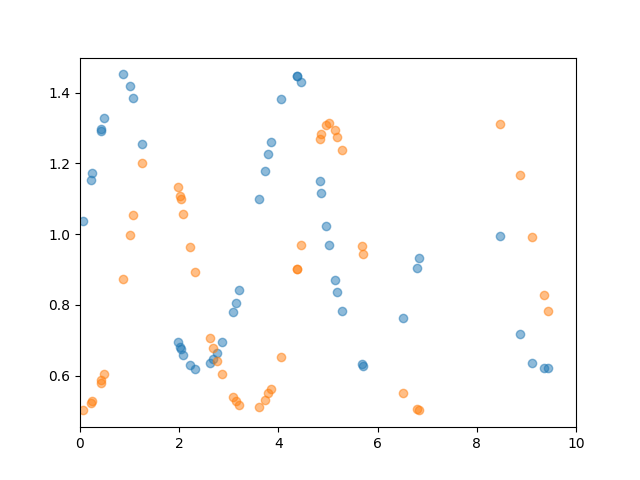

In [50]:
time_evals = node_metadata[:, 4:4+num_timeponts]
predator_trace = data_lv[:, 4:4+num_timeponts]
prey_trace = data_lv[:, 4+num_timeponts:]

fig = plt.figure()
for i in range(1):
    plt.scatter(time_evals[i], predator_trace[i], c='C0', alpha=0.5)
    plt.scatter(time_evals[i], prey_trace[i], c='C1', alpha=0.5)
    plt.xlim(0, 10)


In [103]:

def model_lv(t, x, node_ids, node_metadata, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions

    dim = 210
    _dim = dim // 3
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim, w_init=hk.initializers.RandomNormal(mean=3., stddev=0.01))
    embedding_metadata = SinusoidalEmbedding(_dim)
    embedding_time = SinusoidalEmbedding(_dim)
    

    # Positional embedding

    model = Transformer(num_heads=8, num_layers=8, attn_size=20, dropout_rate=0.0, widening_factor=4)

    # Embed values adn time
    value_embeddings = embedding_net(x)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    time_embeddings = jnp.broadcast_to(time_embeddings, value_embeddings.shape[:-1] + (_dim,))

    # Embed node ids and metadata
    id_embeddings = embedding_id_nets(node_ids)
    metadata_embeddings = embedding_metadata(node_metadata.reshape(-1,x.shape[1],1))
    metadata_embeddings = metadata_embeddings * ~jnp.isnan(metadata_embeddings)
    metadata_embeddings = jnp.broadcast_to(metadata_embeddings, value_embeddings.shape)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)
    node_emebding = id_embeddings

    # Condition embedding
    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal(mean=-3.,stddev=0.1))
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, x.shape[1],1)
    


    x_encoded = jnp.concatenate([value_embeddings, node_emebding, metadata_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding

    # Encode
    h = model(x_encoded, context=time_embeddings)

    # Decode
    out = hk.Linear(1)(h)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [104]:
init_lv, model_fn_lv = hk.transform(model_lv)
params_lv = init_lv(key, jnp.ones(data_lv.shape[0]), data_lv, node_ids, node_metadata, jnp.zeros_like(node_ids))

In [105]:
params_lv = jnp.load("transformer_based_inference_diffusion_lotka_volterra.npz", allow_pickle=True)["arr_0"].item()

In [106]:
from functools import partial

node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
node_metadata = jnp.array([jnp.nan, jnp.nan, jnp.nan, jnp.nan] + list(jnp.linspace(time_start + 0.01, time_end , num_timeponts)) + list(jnp.linspace(time_start +0.01, time_end, num_timeponts))) # Time points
condition_mask = jnp.array([0]*T_max, dtype=int)
condition_value = jnp.array([0]*T_max)

def drift_backward_lv(t, x, node_ids=node_ids, condition_mask=condition_mask, node_metadata=node_metadata):
    #t = T - t
    score = model_fn_lv(params_lv, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,node_metadata, condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask[:len(node_ids)])
    return f

def diffusion_backward_lv(t,x, node_ids=node_ids,node_metadata=node_metadata,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

n_devices = jax.local_device_count()
def sample_fn_lv(key, shape, node_ids=node_ids, node_metadata=node_metadata, time_steps=1000, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward_lv(t, x, node_ids=node_ids, node_metadata=node_metadata,condition_mask= condition_mask), lambda t, x: diffusion_backward_lv(t, x, node_ids=node_ids, condition_mask=condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys[:, -1, :]

In [107]:
samples = jax.pmap(lambda k: sample_fn_lv(k, (200, ), time_steps=300,node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
samples = samples.reshape(-1, len(node_ids))

In [ ]:
%matplotlib widget

condition_mask = jnp.array([0]*T_max, dtype=int)
condition_value = jnp.array([0.]*T_max)

time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]
thetas = samples[:, :4]

fig = plt.figure(figsize=(10, 5))
grid = plt.GridSpec(2, 3, width_ratios=[1, 1, 4])

mean_predator = predator_trace.mean(axis=0)
min_predator = jnp.quantile(predator_trace, 0.025, axis=0)
max_predator = jnp.quantile(predator_trace, 0.975, axis=0)
mean_prey = prey_trace.mean(axis=0)
min_prey = jnp.quantile(prey_trace, 0.025, axis=0)
max_prey = jnp.quantile(prey_trace, 0.975, axis=0)

ax_right = plt.subplot(grid[0, 2])
ax_right2 = plt.subplot(grid[1, 2])
ax_upper_left = plt.subplot(grid[0, 0])
ax_lower_left = plt.subplot(grid[1, 0])
ax_upper_middle = plt.subplot(grid[0, 1])
ax_lower_middle = plt.subplot(grid[1, 1])

t1 =ax_upper_left.hist(thetas[:, 0], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_upper_left.set_title(r"$\alpha$")
t2 = ax_upper_middle.hist(thetas[:, 1], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_upper_middle.set_title(r"$\beta$")
t3 = ax_lower_left.hist(thetas[:, 2], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_lower_left.set_title(r"$\gamma$")
t4 = ax_lower_middle.hist(thetas[:, 3], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_lower_middle.set_title(r"$\delta$")

m_pred = ax_right.plot(time_evals, mean_predator, c='red', lw=2)
m_prey = ax_right2.plot(time_evals, mean_prey, c='blue', lw=2)
q_pred = ax_right.fill_between(time_evals, min_predator, max_predator, alpha=0.1, color='red')
q_prey = ax_right2.fill_between(time_evals, min_prey, max_prey, alpha=0.1, color='blue')
linestyles = [':', '--']

t1_pred = ax_right.plot(time_evals, predator_trace[0], c='red', alpha=0.5, linestyle=linestyles[0])
t1_prey = ax_right2.plot(time_evals, prey_trace[0], c='blue', alpha=0.5, linestyle=linestyles[0])
t2_pred = ax_right.plot(time_evals, predator_trace[1], c='red', alpha=0.5, linestyle=linestyles[1])
t2_prey = ax_right2.plot(time_evals, prey_trace[1], c='blue', alpha=0.5, linestyle=linestyles[1])
    
ax_right.set_xlim(0, 10)
ax_right.set_title("Predator")
ax_right.set_xlabel("Time")
ax_right.set_ylabel("Population density")
ax_right2.set_xlim(0, 10)
ax_right2.set_title("Prey")
ax_right2.set_xlabel("Time")
ax_right2.set_ylabel("Population density")


l1 = None 
l2 = None
l3 = None
l4 = None

dots_prey = [None] * len(time_evals)
dots_predator = [None] * len(time_evals)

def onclick(event):
    global l1,l2,l3,l4
    global condition_mask, condition_value
    global time_evals
    global dots_predator, dots_prey
    global m_pred, m_prey, q_pred, q_prey, t1_pred, t1_prey, t2_pred, t2_prey
    global t1, t2, t3, t4
    global ax_right, ax_right2, ax_upper_left, ax_upper_middle, ax_lower_left, ax_lower_middle  
    ax = event.inaxes

    if ax is None:
        
        samples = jax.pmap(lambda k: sample_fn_lv(k, (100, ), time_steps=200,node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
        samples = samples.reshape(-1, len(node_ids))
 
        m_pred[0].remove()
        m_prey[0].remove()
        q_pred.remove()
        q_prey.remove()
        t1_pred[0].remove()
        t1_prey[0].remove()
        t2_pred[0].remove()
        t2_prey[0].remove()
        try:
            t1[-1].remove()
        except:
            pass
        try:
            t2[-1].remove()
        except:
            pass
        try:
            t3[-1].remove()
        except:
            pass
        try:
            t4[-1].remove()
        except:
            pass
  
        time_evals = node_metadata[4:4 + num_timeponts]
        predator_trace = samples[:, 4:4 + num_timeponts]
        prey_trace = samples[:, 4+num_timeponts:]
        mean_predator = predator_trace.mean(axis=0)
        min_predator = jnp.quantile(predator_trace, 0.025, axis=0)
        max_predator = jnp.quantile(predator_trace, 0.975, axis=0)
        mean_prey = prey_trace.mean(axis=0)
        min_prey = jnp.quantile(prey_trace, 0.025, axis=0)
        max_prey = jnp.quantile(prey_trace, 0.975, axis=0)
        thetas = samples[:, :4]
        theta1 = thetas[:, 0]
        theta2 = thetas[:, 1]
        theta3 = thetas[:, 2]
        theta4 = thetas[:, 3]
        
        if l1 is None:
            t1 =ax_upper_left.hist(theta1,  alpha=0.5, edgecolor='black', density=True, color="C0")
        if l2 is None:
            t2 = ax_upper_middle.hist(theta2, alpha=0.5, edgecolor='black', density=True, color="C0")
        if l3 is None:
            t3 = ax_lower_left.hist(theta3, alpha=0.5, edgecolor='black', density=True, color="C0")
        if l4 is None:
            t4 = ax_lower_middle.hist(theta4, alpha=0.5, edgecolor='black', density=True, color="C0")
        

        m_pred =ax_right.plot(time_evals, mean_predator, c='red', lw=2)
        m_prey = ax_right2.plot(time_evals, mean_prey, c='blue', lw=2)
        q_pred =ax_right.fill_between(time_evals, min_predator, max_predator, alpha=0.1, color='red')
        q_prey=ax_right2.fill_between(time_evals, min_prey, max_prey, alpha=0.1, color='blue')
        linestyles = [':', '--']
   
        t1_pred =ax_right.plot(time_evals, predator_trace[0], c='red', alpha=0.5, linestyle=linestyles[0])
        t1_prey =ax_right2.plot(time_evals, prey_trace[0], c='blue', alpha=0.5, linestyle=linestyles[0])
        t2_pred =ax_right.plot(time_evals, predator_trace[1], c='red', alpha=0.5, linestyle=linestyles[1])
        t2_prey =ax_right2.plot(time_evals, prey_trace[1], c='blue', alpha=0.5, linestyle=linestyles[1])
        
        return
            
    else:
        x_data, y_data =  ax.transData.inverted().transform((event.x, event.y))
        
        if ax is ax_right:
            index = jnp.searchsorted(time_evals, jnp.array(x_data))
            t = float(time_evals[index])
            if dots_predator[index] is not None:
                dots_predator[index].remove()
                dots_predator[index] = None
                condition_mask = condition_mask.at[4 + index].set(0)
            else:
                dot = ax_right.scatter(t, y_data, c='red')
                dots_predator[index] = dot
                condition_value = condition_value.at[4 + index].set(y_data)
                condition_mask = condition_mask.at[4 +index].set(1)
        if ax is ax_right2:
            
            index = jnp.searchsorted(time_evals, jnp.array(x_data))
            t = float(time_evals[index])
            if dots_prey[index] is not None:
                dots_prey[index].remove()
                dots_prey[index] = None
                condition_mask = condition_mask.at[4  + num_timeponts + index].set(0)
            else:
                dot = ax_right2.scatter(t, y_data, c='blue')
                dots_prey[index] = dot
                condition_value = condition_value.at[4  +num_timeponts+ index].set(y_data)
                condition_mask = condition_mask.at[4  + num_timeponts+index].set(1)
        elif ax is ax_upper_left:
            if l1 is not None:
                l1.remove()
                l1 = None
                condition_mask = condition_mask.at[0].set(0)
                return
            l1 = ax_upper_left.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[0].set(1)
            condition_value = condition_value.at[0].set(x_data)
        elif ax is ax_upper_middle:
            if l2 is not None:
                l2.remove()
                l2 = None
                condition_mask = condition_mask.at[1].set(0)
                return
            l2 = ax_upper_middle.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[1].set(1)
            condition_value = condition_value.at[1].set(x_data)
        elif ax is ax_lower_left:
            if l3 is not None:
                l3.remove()
                l3 = None
                condition_mask = condition_mask.at[2].set(0)
                return
            l3 = ax_lower_left.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[2].set(1)
            condition_value = condition_value.at[2].set(x_data)
        elif ax is ax_lower_middle:
            if l4 is not None:
                l4.remove()
                l4 = None
                condition_mask = condition_mask.at[3].set(0)
                return
            l4 = ax_lower_middle.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[3].set(1)
            condition_value = condition_value.at[3].set(x_data)
        
fig.tight_layout()

fig.canvas.mpl_connect('button_press_event', onclick)

## Classifier free guidance


In [25]:

def guided_sample_fn(key, shape, alpha=0.1,node_ids=node_ids, time_steps=500, condition_mask=jnp.zeros((nodes_max,), dtype=int), condition_value=jnp.zeros((nodes_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    keys = jrandom.split(key2, shape)
    
    def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask):
        #t = T - t
        x_embd = x.reshape(-1, len(node_ids), 1)
        score = model_fn(params, key, t.reshape(-1, 1, 1), x_embd, node_ids,jnp.zeros((len(node_ids),)))
        x_condition = (1- condition_mask[:len(node_ids)]) * x_embd + condition_mask[:len(node_ids)] * condition_value.reshape(1, len(node_ids), 1)
        score_conditioned = model_fn(params, key, t.reshape(-1, 1, 1), x_condition, node_ids, condition_mask[:len(node_ids)])
        
        score =  (1 + alpha) * score_conditioned.reshape(x.shape) - alpha * score.reshape(x.shape)
        score = score.reshape(x.shape)

        f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
        f = f * (1-condition_mask[:len(node_ids)])
        return f

    def diffusion_backward(t,x, node_ids=node_ids,condition_mask=condition_mask):
        #t = T - t
        b =  diffusion_fn(x, t)
        b = b * (1-condition_mask[:len(node_ids)])
        return b
    
    
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids, condition_mask), lambda t, x: diffusion_backward(t, x, node_ids, condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys

In [26]:
guided_samples = guided_sample_fn(jrandom.PRNGKey(1), (2000, ), alpha=0.9, node_ids=jnp.array([0, 1]), condition_mask=jnp.array([0, 1]), condition_value=jnp.array([0., 0.]))

ValueError: 'mlp/~/linear_0/w' with retrieved shape (1, 20) does not match shape=[2, 20] dtype=dtype('float32')